# Least squares fitting of a straight line

This notebook demonstrates a simple least-squares fit to noisy data. We fit a straight line

$$
y = mx + b + \epsilon
$$

to a set of measured points and compare the fitted line with the underlying trend. Following the line-fitting tutorial on the emcee documentation, this is the standard approach for estimating the best-fit parameters from Gaussian noise.


Least-squares estimates:
m = -1.104 ± 0.016
b = 5.441 ± 0.091
True parameters: -0.9594 4.294


/tmp/ipykernel_361912/2550520094.py:50: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/least_squares_fit.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_361912/2550520094.py:50: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/least_squares_fit.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_361912/2550520094.py:50: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/least_squares_fit.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_361912/2550520094.py:50: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_res

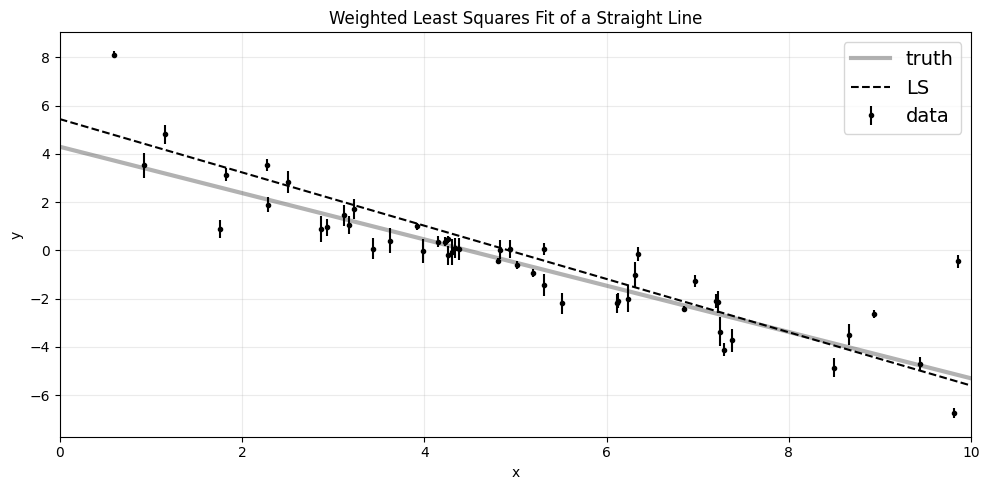

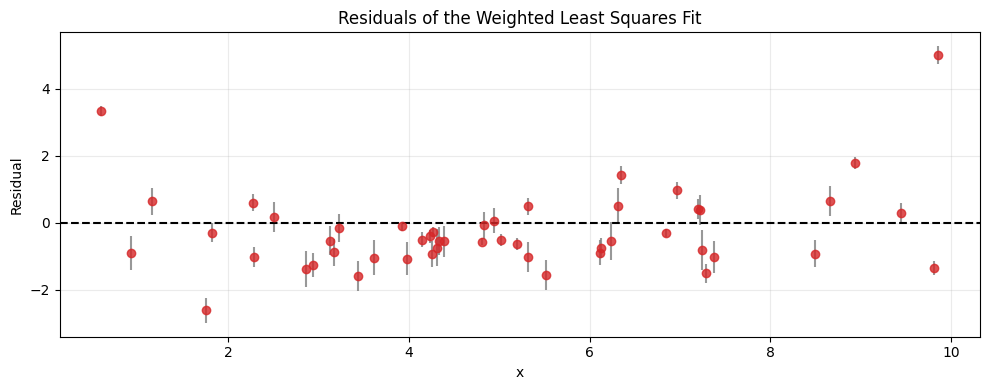

In [11]:
import os

import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

os.makedirs("Figures", exist_ok=True)

np.random.seed(123)

# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534

# Generate some synthetic data from the model.
N = 50
x = np.sort(10 * np.random.rand(N))
yerr = 0.1 + 0.5 * np.random.rand(N)
y = m_true * x + b_true
y += np.abs(f_true * y) * np.random.randn(N)
y += yerr * np.random.randn(N)


x0 = np.linspace(0, 10, 500)
A = np.vander(x, 2)
C = np.diag(yerr * yerr)
ATA = np.dot(A.T, A / (yerr**2)[:, None])
cov = np.linalg.inv(ATA)
w = np.linalg.solve(ATA, np.dot(A.T, y / yerr**2))

print("Least-squares estimates:")
print("m = {0:.3f} ± {1:.3f}".format(w[0], np.sqrt(cov[0, 0])))
print("b = {0:.3f} ± {1:.3f}".format(w[1], np.sqrt(cov[1, 1])))
print("True parameters:", m_true, b_true)

plt.figure(figsize=(10, 5))
plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0, label="data")
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3, label="truth")
plt.plot(x0, np.dot(np.vander(x0, 2), w), "--k", label="LS")
plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Weighted Least Squares Fit of a Straight Line")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("Figures/least_squares_fit.png", dpi=300, bbox_inches="tight")

plt.figure(figsize=(10, 4))
residuals = y - np.dot(np.vander(x, 2), w)
plt.errorbar(x, residuals, yerr=yerr, fmt="o", color="tab:red", ecolor="tab:gray", alpha=0.8)
plt.axhline(0.0, color="black", linewidth=1.5, linestyle="--")
plt.xlabel("x")
plt.ylabel("Residual")
plt.title("Residuals of the Weighted Least Squares Fit")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("Figures/least_squares_residuals.png", dpi=300, bbox_inches="tight")

plt.show()